# Assignment 2: Data Modelling - Dry Bean Dataset


* Dataset: Dry Bean dataset
* Task : Classification
* Models used: K-Nearest Neighbors (KNN) and Decision Tree

## Import Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker
from sklearn.metrics import precision_recall_fscore_support
import joblib


## Task 1: Retrieving and Preparing the Data	

* Goal: 
    The goal of this project is to build classification model that can automatically identify class of dry bean from its physical measurements. 

### 1.1 Data loading

In [88]:
filename ='Dataset 1 - Dry Bean/Dry_Bean_dataset.csv'
df = pd.read_csv(filename)

In [89]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


### 1.2 Initial Inspection

In [90]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [92]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [93]:
df.dtypes

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [94]:
df['Class'] = df['Class'].astype('category')

### 1.3 Remove the Duplicate records

In [95]:
df.duplicated().sum()

np.int64(68)

In [96]:
df.drop_duplicates(inplace=True)

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.shape

(13543, 17)

### 1.4 Missing Value Analysis

In [99]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

### 1.5 Outlier Detection
As this is a biological dataset most of the outliers are not the error but they are real bean variations.

In [100]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_out

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_df['% of Total'] = (outlier_df['Outlier Count'] / len(df) * 100).round(2)
print(outlier_df)

                 Outlier Count  % of Total
Area                       551        4.07
Perimeter                  500        3.69
MajorAxisLength            379        2.80
MinorAxisLength            567        4.19
AspectRation               485        3.58
Eccentricity               833        6.15
ConvexArea                 549        4.05
EquivDiameter              526        3.88
Extent                     271        2.00
Solidity                   774        5.72
roundness                   98        0.72
Compactness                124        0.92
ShapeFactor1               533        3.94
ShapeFactor2                 0        0.00
ShapeFactor3               202        1.49
ShapeFactor4               760        5.61


In [101]:
df.shape

(13543, 17)

## Task 2: Data Exploration

### 2.1 Individual column Exploration using histogram with KDE

In [102]:
numeric_cols = df.select_dtypes(include='number').columns

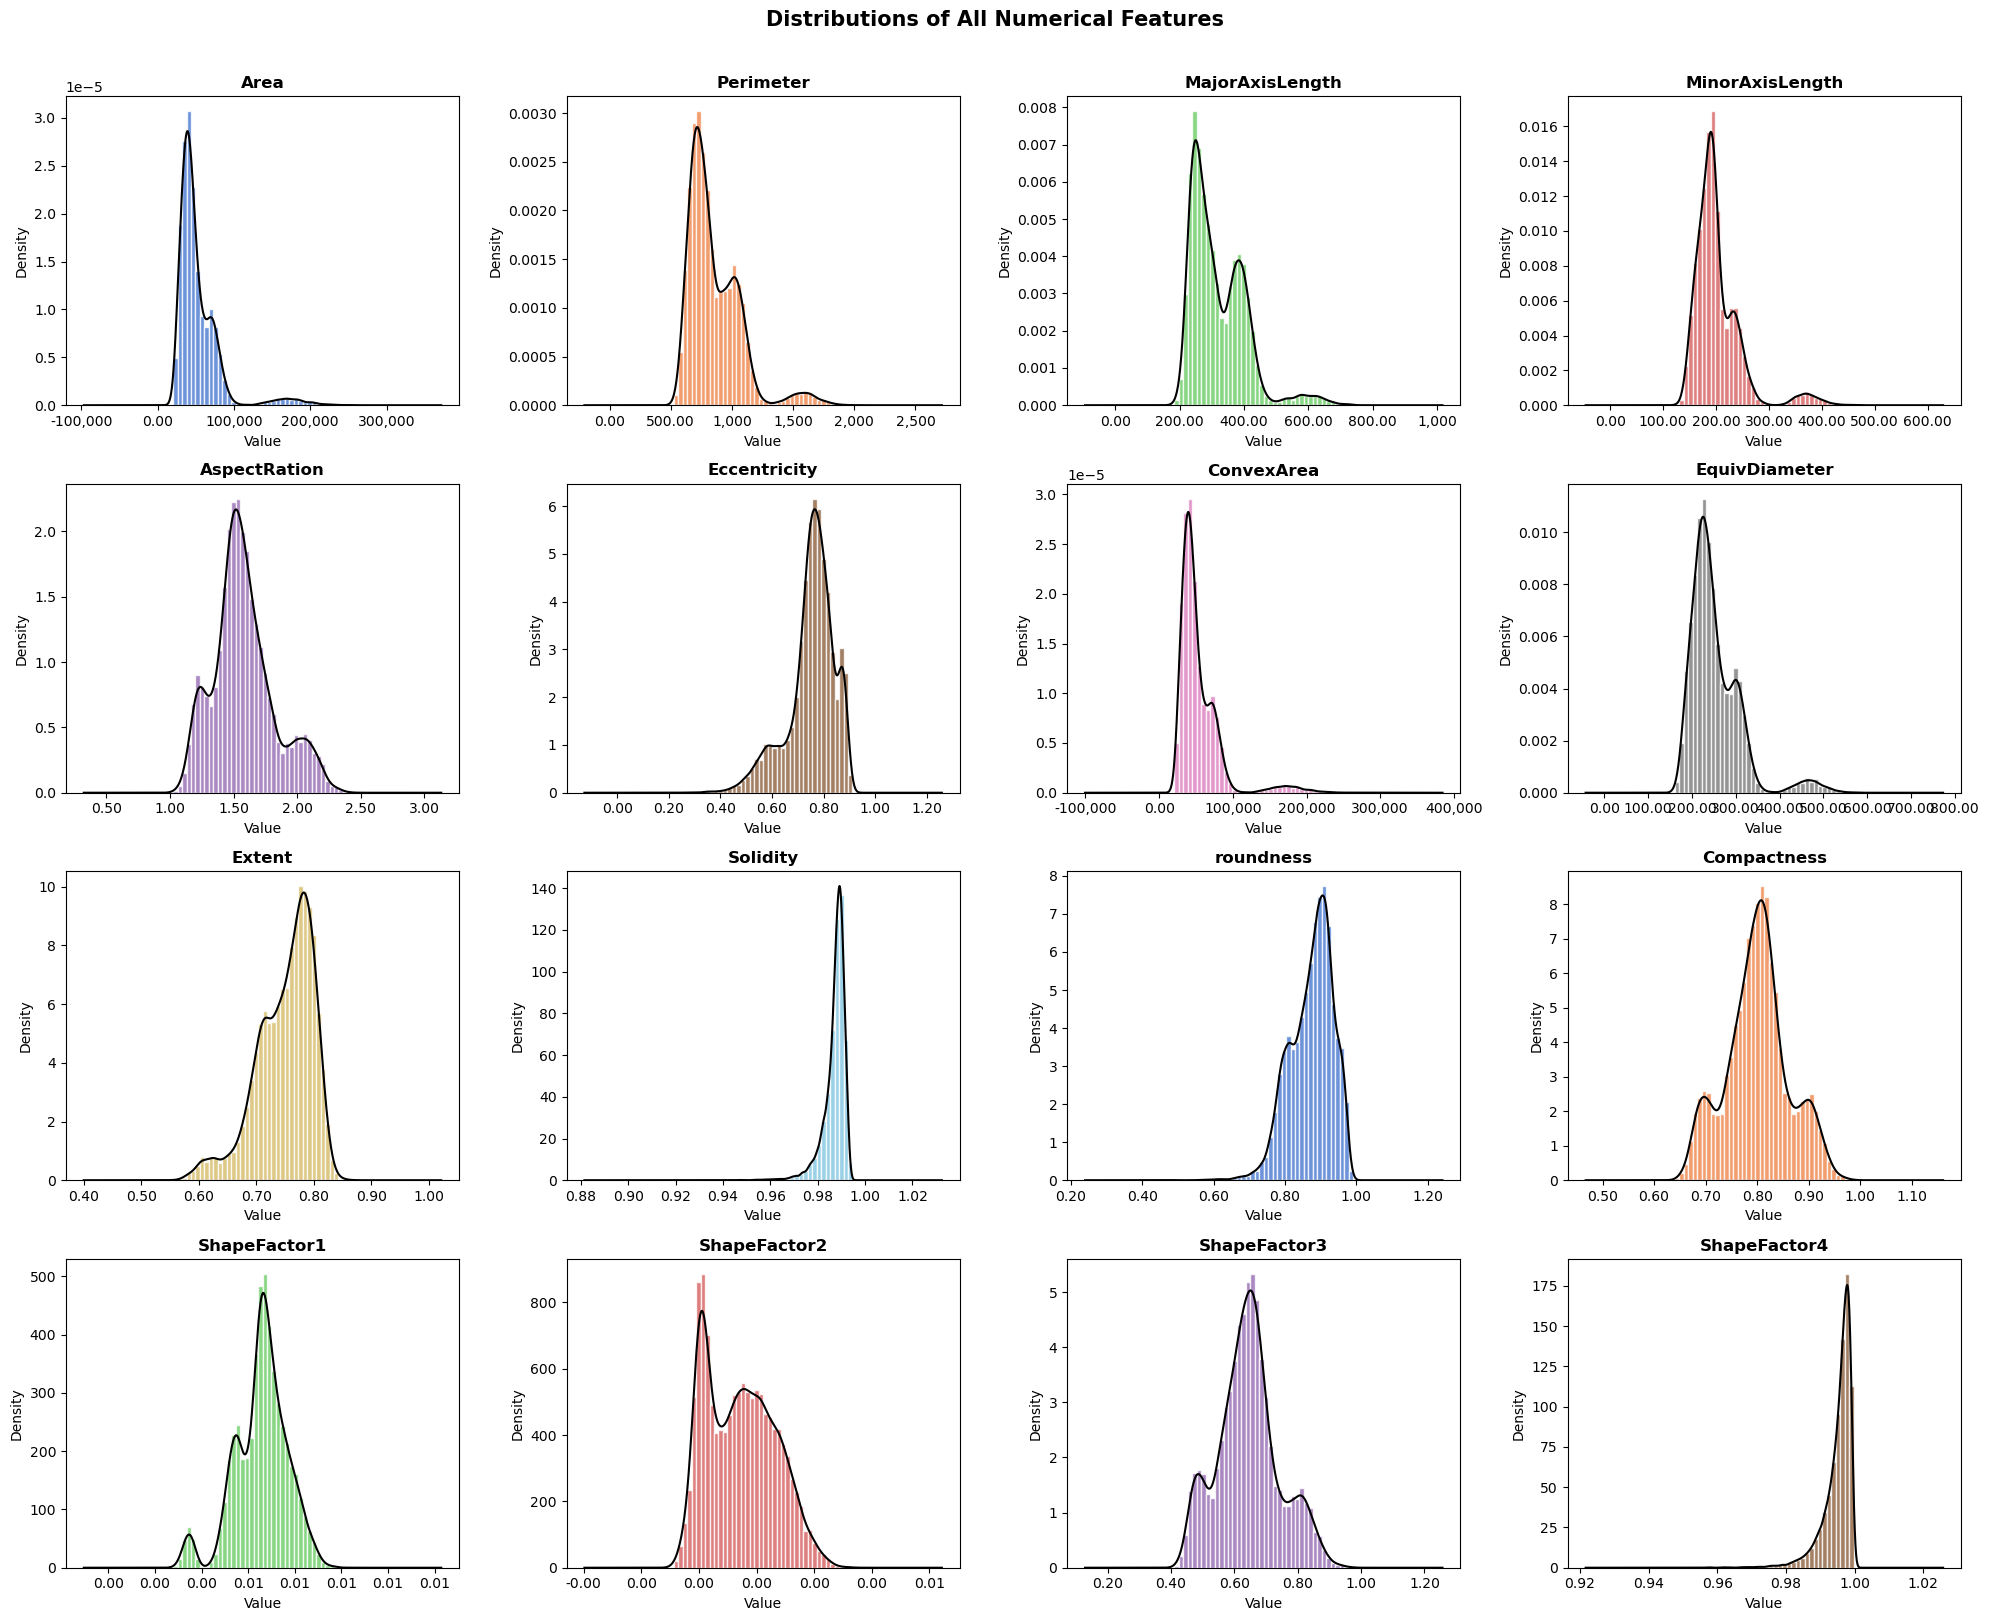

In [103]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))   
axes = axes.flatten()                             

colors = sns.color_palette('muted', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    ax.hist(df[col],bins=40,color=colors[i],edgecolor='white',alpha=0.8,density=True)

    df[col].plot(kind='kde',ax=ax,color='black',linewidth=1.5)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'{x:,.0f}' if abs(x) > 999 else f'{x:.2f}'
        )
    )

plt.suptitle(
    'Distributions of All Numerical Features',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

**Observations from the graph**
* The columns such as Area, Perimeter, MajorAxisLength, ConvexArea, EquivDiameter are right skewed meaning distinct size ranges of the seven bean clases.
*  The columns AspectRation, Eccentricity are roughly right-skewed menaing that most of the beans have more circular or compact shape.
* The Solidity, roundness, Compactness, shapeFactor4 are left skewed means they are mostly rounded and compact.
* The shapeFactor1, shapeFactor2, shapeFactor3 are almost symmetric shows that the shape based properties are more consistent.

### 2.2 Class and column exploration with boxplot

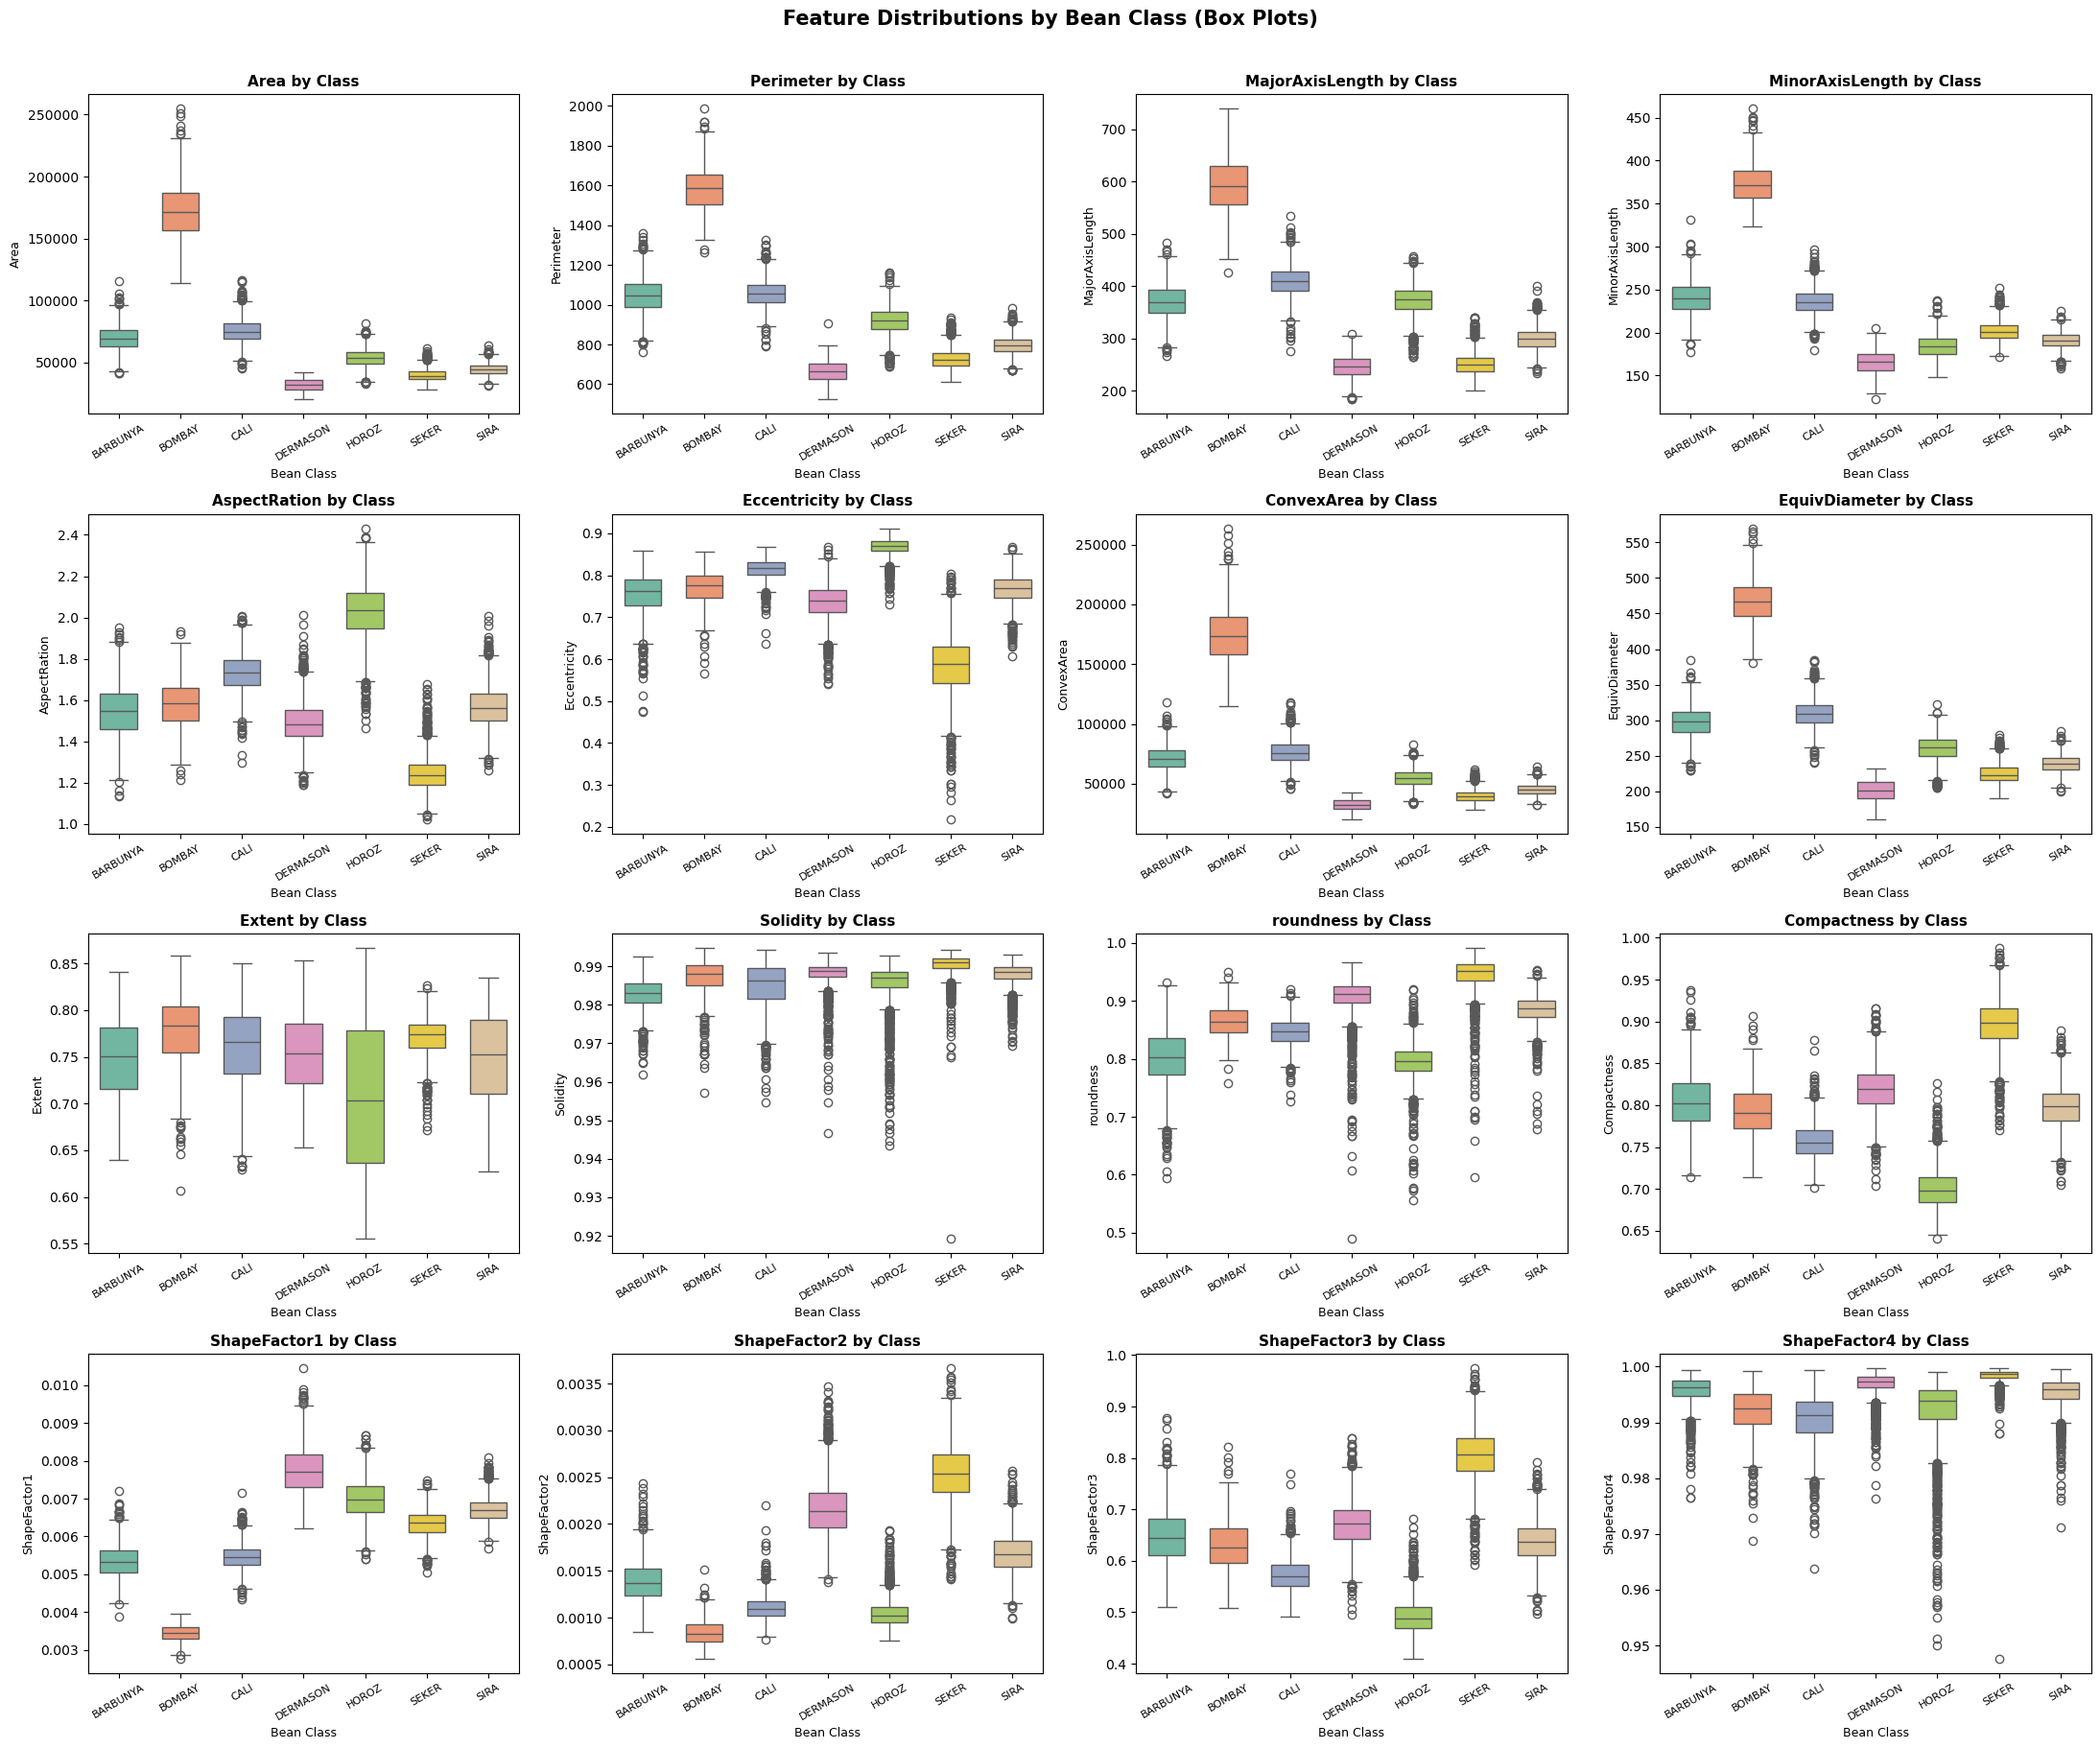

In [104]:
fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

bean_palette = sns.color_palette('Set2', df['Class'].nunique())

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(
        data=df, x='Class', y=col,
        palette=bean_palette, ax=ax,
        order=sorted(df['Class'].unique()),
        width=0.6, linewidth=1.0
    )
    ax.set_title(f'{col} by Class', fontsize=11, fontweight='bold')
    ax.set_xlabel('Bean Class', fontsize=9)
    ax.set_ylabel(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Feature Distributions by Bean Class (Box Plots)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations from Box Plots by Class**
* The 'BOMBAY' beans are clearly separated from all others in 'Area, Perimeter, Convex Area, EquivDiameter'- they are considerably larger, making it a significant discriminating feature.
* Aspect Ratio and Eccentricity: HOROZ beans are visibly more elongated than other classes.
* ShapeFactor1 and ShapeFactor2: The 'DERMASON' and 'SEKER' show the more distinct ranges.


### 2.3 Correlation: Finding the correlation between column using heatmap

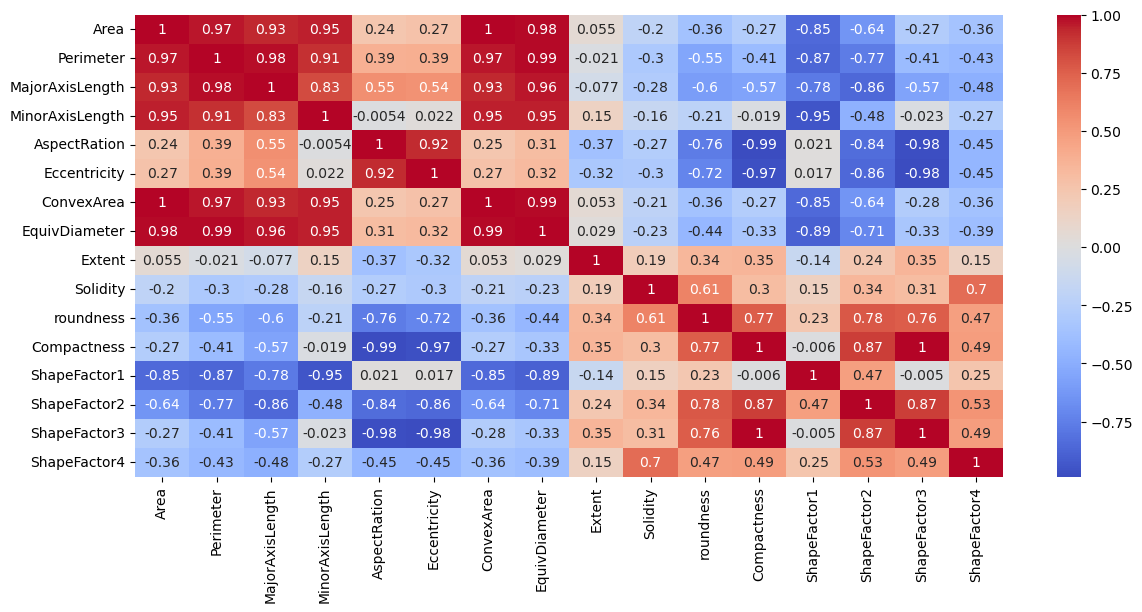

In [105]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()
plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**Observations from Heatmap**
* The correlation heatmap shows that size‑related features such as Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, and EquivDiameter are strongly positively correlated, meaning they measure similar physical dimensions of beans.
* In contrast, shape‑based features like Compactness, Roundness, and ShapeFactors are negatively correlated with size features, indicating that larger beans tend to be less compact.

### 2.4 Class Distribution

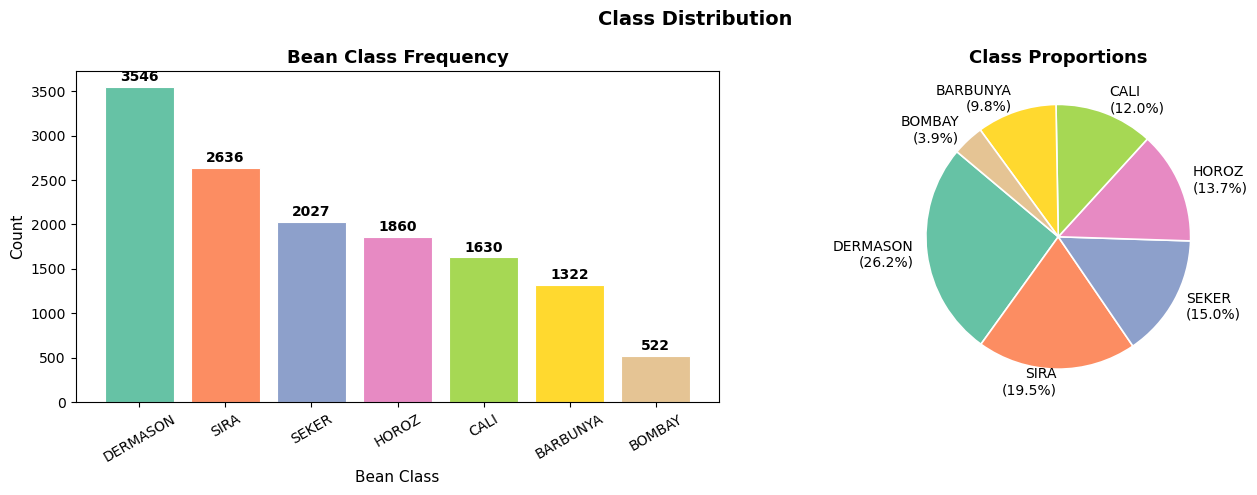

In [106]:
class_counts = df['Class'].value_counts().sort_values(ascending=False)
class_pct    = (class_counts / len(df) * 100).round(1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(class_counts.index,class_counts.values,color=sns.color_palette('Set2', len(class_counts)),edgecolor='white',linewidth=0.8)


for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(val),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_title('Bean Class Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bean Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# 2. PIE CHART
axes[1].pie(
    class_counts.values,
    labels=[f'{c}\n({p}%)' for c, p in zip(class_counts.index, class_pct)],
    colors=sns.color_palette('Set2', len(class_counts)),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()

**Observation from the class Distributionn**
* The class distribution shows that the dataset is moderately imbalanced.
* 'DERMASON' is most common class with 26.2% while 'BOMBAY' is the rarest with 3.8% contribution.
* This signifies that stratified splitting during train/test split which preserves the class proportions. 

### 2.5 Exploring the individual columns

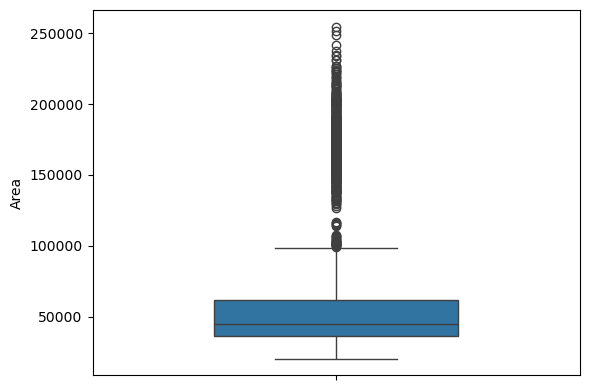

In [107]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Area'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

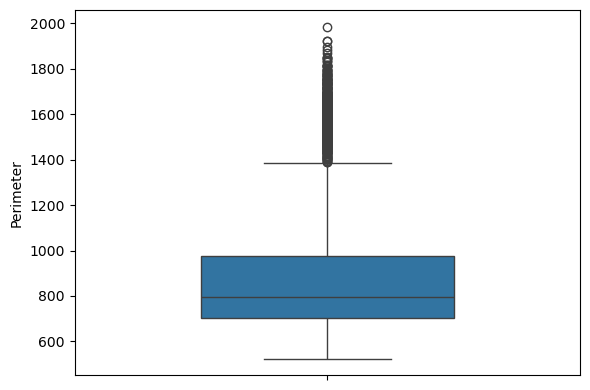

In [108]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Perimeter'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

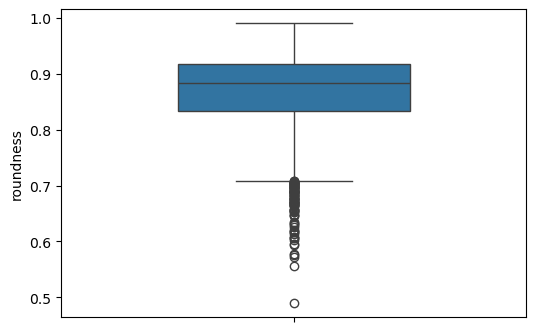

In [109]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['roundness'],width=.5)
plt.show()

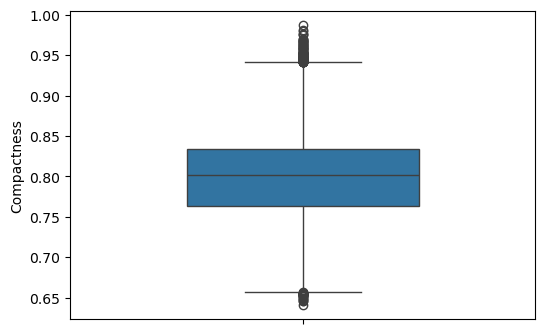

In [110]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Compactness'],width=.5)
plt.show()

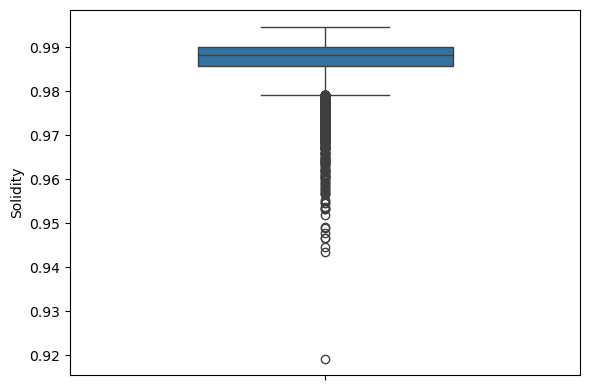

In [111]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Solidity'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

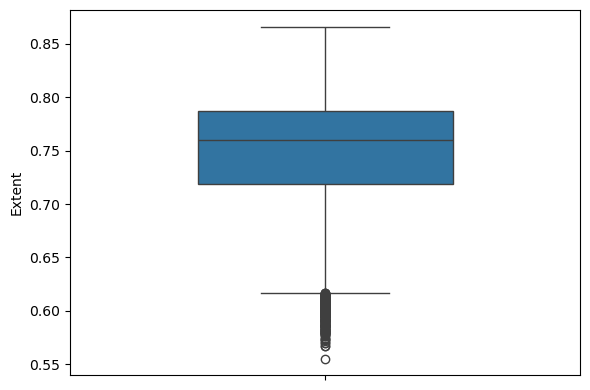

In [112]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df['Extent'],width=.5)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

**Observation**
The above individual boxplot of the columns helps to understand the spread of each column. Also the outliers seen are the values for any particular bean type.

### 2.6 Analysing ShapeFactor Columns

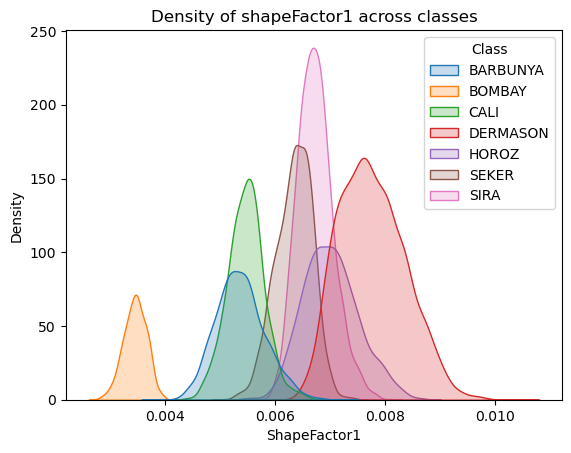

In [113]:
sns.kdeplot(data=df, x='ShapeFactor1', hue='Class', fill=True)
plt.title("Density of shapeFactor1 across classes")
plt.show()

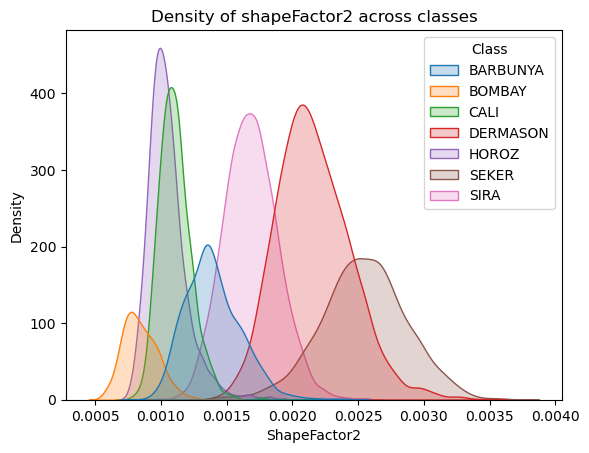

In [114]:
sns.kdeplot(data=df, x='ShapeFactor2', hue='Class', fill=True)
plt.title("Density of shapeFactor2 across classes")
plt.show()

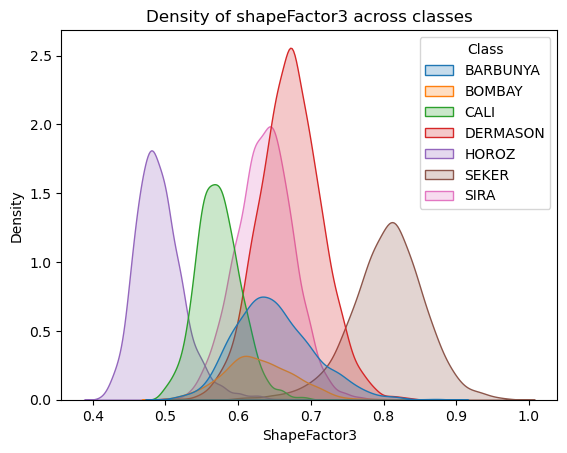

In [115]:
sns.kdeplot(data=df, x='ShapeFactor3', hue='Class', fill=True)
plt.title("Density of shapeFactor3 across classes")
plt.show()

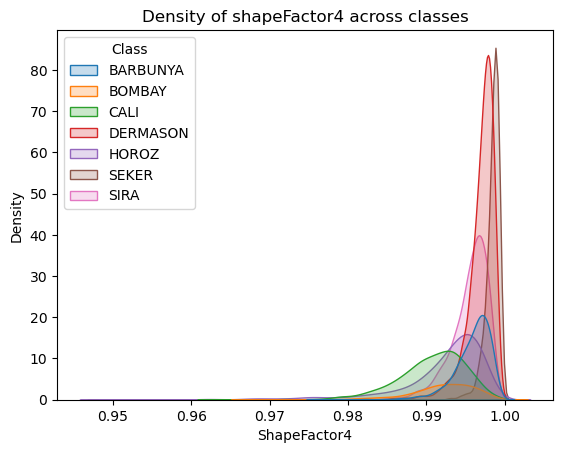

In [116]:
sns.kdeplot(data=df, x='ShapeFactor4', hue='Class', fill=True)
plt.title("Density of shapeFactor4 across classes")
plt.show()

### Relationships Analysis

**Pair 1:** Area vs Perimeter 

**Hypothesis**: Larger beans have large perimeters.

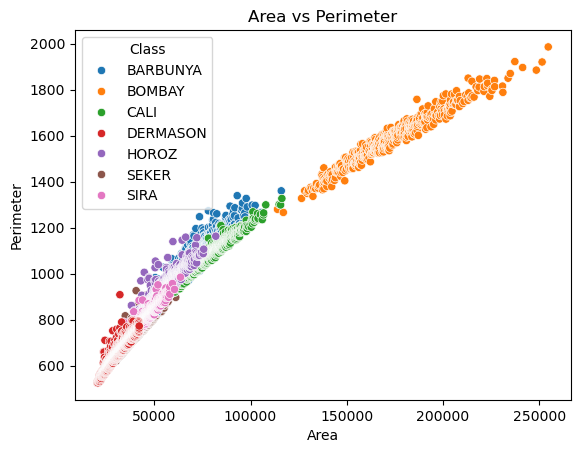

In [117]:
sns.scatterplot(x='Area', y='Perimeter', hue='Class', data=df)
plt.title("Area vs Perimeter")
plt.show()

**Observation**
There is positive linear relationship. Each class occupies a distinct region of the plot.'BOMBAY' sits far to the upper right indicating that it is the largest bean. While 'DERMASON' and 'SEKER' overlap at the lower end.

**Pair 2:** Area vs Eccentricity 

**Hypothesis**: Bean area and eccentricity are largely independent.

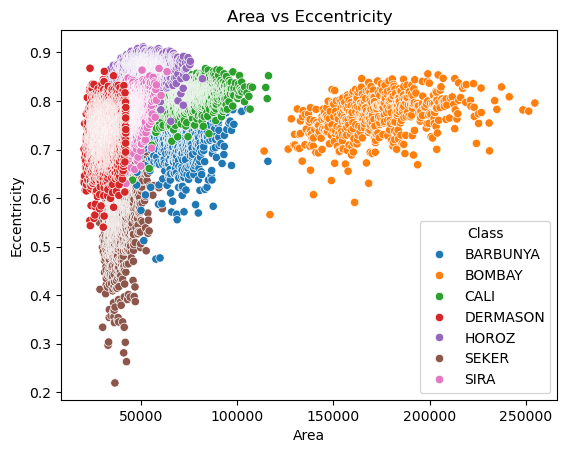

In [118]:
sns.scatterplot(data=df,x='Area',y='Eccentricity',hue='Class')
plt.title("Area vs Eccentricity")
plt.show()

**Observation**
It is confirmed that there is no direct correlation between between Area and eccentricity. However clear class based clusters are visible. These both features can help separate classes that are otherwise difficult to distinguish.

**Pair 3:** Roundness vs Compactness

**Hypothesis**: The compact beans should also be rounded in shape.

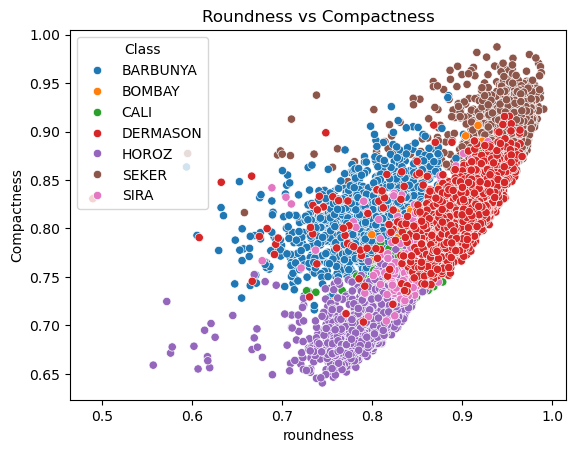

In [119]:
sns.scatterplot(data=df,x='roundness',y='Compactness',hue='Class')
plt.title("Roundness vs Compactness")
plt.show()

**Observation**
There is a positive correlation. The separation can be seen between the classes. Also it shows that as the compactness increases the roundness also increases. 

**Pair 4:** Aspect Ratio vs Eccentricity

**Hypothesis**: Elongated beans will higher aspect ratio.

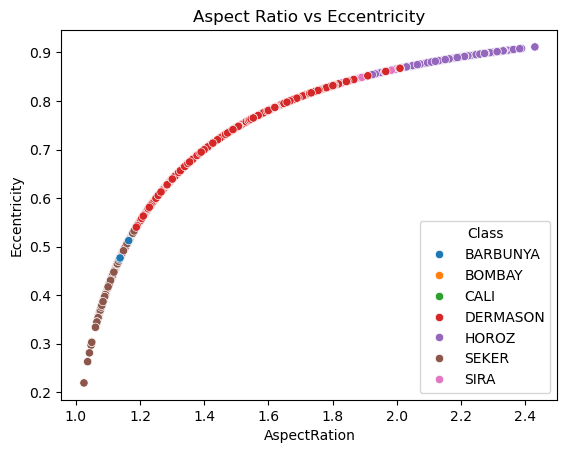

In [120]:
sns.scatterplot(data=df,x='AspectRation',y='Eccentricity',hue='Class')
plt.title("Aspect Ratio vs Eccentricity")
plt.show()

**Observation**
Very strong positive non-linear correlation. Here 'SEKER' occupy lower left that indicates its more circular shape. While 'HOROZ' occupy upper left part indicating elongated shape.

**Pair 5:** EquivDiameter vs Perimeter

**Hypothesis**: Larger diameter beans have longer perimeters.

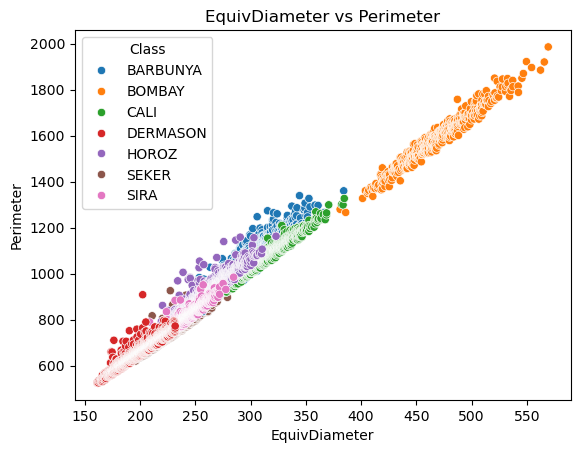

In [121]:
sns.scatterplot(data=df,x='EquivDiameter',y='Perimeter',hue='Class')
plt.title("EquivDiameter vs Perimeter")
plt.show()

**Observation**: Strong positive relationship with a slight fan shape - for a given diameter, elongated beans have relatively longer perimeter because their non-circular contour adds extra boundary length. 

**Pair 6:** Area vs Shape Factor 1

**Hypothesis**: ShapeFactor1 decreases as bean grows.

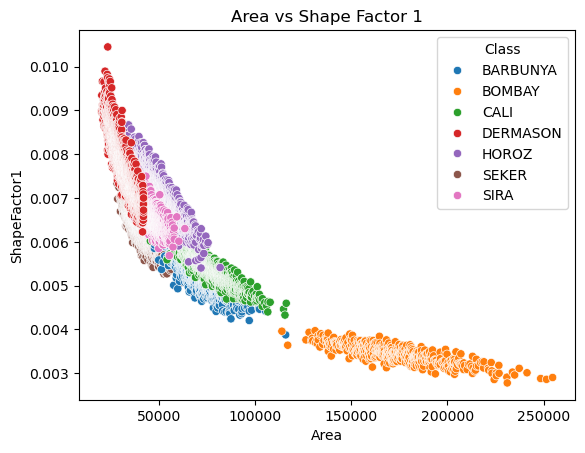

In [122]:
sns.scatterplot(data=df,x='Area',y='ShapeFactor1',hue='Class')
plt.title("Area vs Shape Factor 1")
plt.show()

**Observation**: Clear negative hyperbolic relationship. 'BOMBAY' beans with larger area have lowest ShapeFactor1. This confims ShapeFactor1 encodes size-normalised shape information.

**Pair 7:** Major Axis Length vs Minor Axis Length

**Hypothesis**: Larger beans have longer minor and major axis.

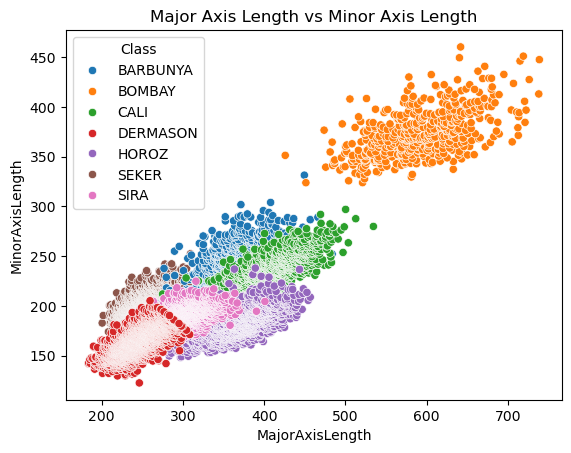

In [123]:
sns.scatterplot(data=df,x='MajorAxisLength',y='MinorAxisLength',hue='Class')
plt.title("Major Axis Length vs Minor Axis Length")
plt.show()

**Observation**
Strong positive correlation. The 'HOROZ' beans shows higher major axis values but relatively lower minor axis value, confirming their elongated shape.

**Pair 8:** Shape Factor 2 vs Shape Factor 3

**Hypothesis**: These normalised shape factors are correlated, with classes separating diagonally.

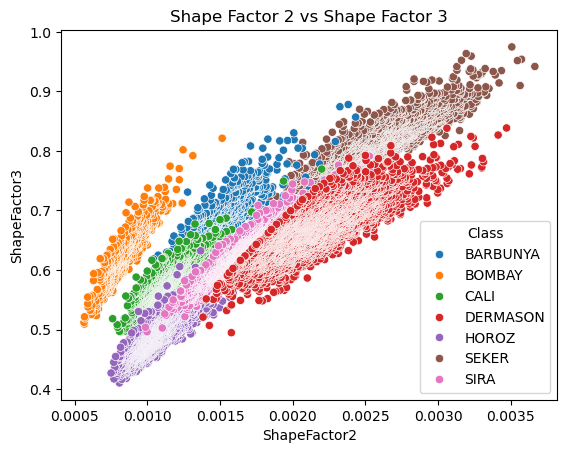

In [124]:
sns.scatterplot(x='ShapeFactor2', y='ShapeFactor3', hue='Class', data=df)
plt.title("Shape Factor 2 vs Shape Factor 3")
plt.show()

**Observation:** Strong positive correlation. 'DERASON' and 'SEKER' cluster together at high ShapeFactor3, while 'HOROZ' and 'SIRA' cluster at low ShapeFactor3 and varying ShapeFactor2. This pair contributes strong discriminative information.

**Pair 9:** Extent vs Area

**Hypothesis**: Beans with a larger Extent value will generally have a larger Area.

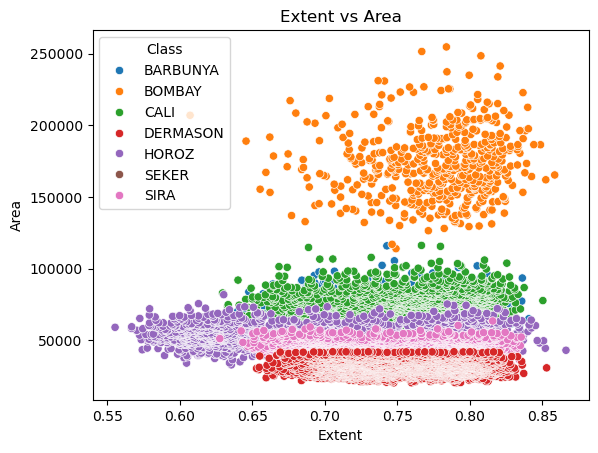

In [125]:
sns.scatterplot(data=df,x='Extent',y='Area',hue='Class')
plt.title("Extent vs Area")
plt.show()

**Observation**: The scatter plot shows a weak to moderate positive relationship between Extent and Area. Different bean classes form distinct clusters, indicating that bean type influences both size and shape characteristics. Some classes have consistently larger areas even with similar extent values, suggesting that Extent alone does not fully determine bean size.

**Pair 10:** Perimeter vs Convex Area

**Hypothesis**: Beans with a larger Perimeter are expected to have a larger ConvexArea.

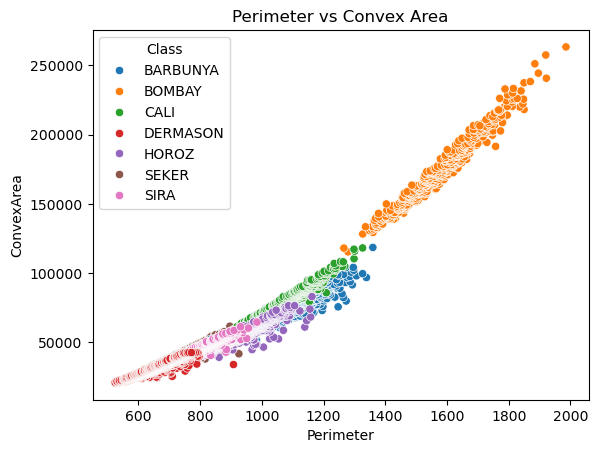

In [126]:
sns.scatterplot(data=df,x='Perimeter',y='ConvexArea',hue='Class')
plt.title("Perimeter vs Convex Area")
plt.show()

**Observation**:The scatter plot shows a strong positive relationship between Perimeter and ConvexArea. As the perimeter increases, the convex area also increases significantly. Different bean classes form noticeable clusters, indicating that bean types have distinct size and shape characteristics. L

**Pair 11:** Extent vs Solidity

**Hypothesis**: Beans that fill their bounding box (high Extent) also fill their convex hull (high Solidity).

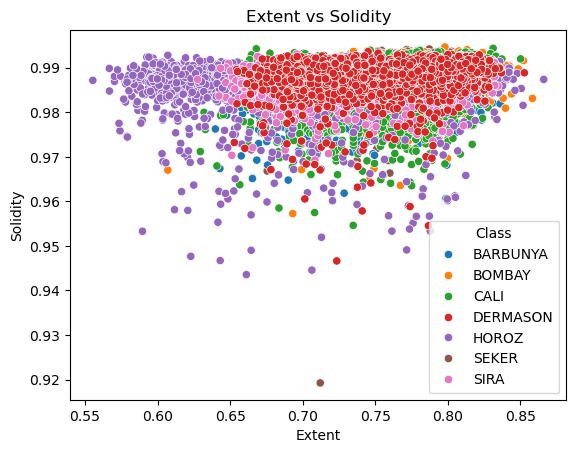

In [127]:
sns.scatterplot(x='Extent', y='Solidity', hue='Class', data=df)
plt.title("Extent vs Solidity")
plt.show()

**Observation**: Week positive correlation. Solidity is high for almost all beans near to 1.0, meaning the bean surface has very few concavities. Extent is more variable. 

## Task 3: Data modelling 

#### 3.1 Feature Selection and train-test split

In [128]:
X = df.drop('Class',axis=1)

In [129]:
y = df['Class']

In [130]:
print("Features Shape:", X.shape)

Features Shape: (13543, 16)


In [131]:
print("Target Shape:", y.shape)

Target Shape: (13543,)


In [132]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [133]:
X_train.shape

(10834, 16)

In [134]:
X_test.shape

(2709, 16)

In [135]:
print("Class distribution in training set:")
print(y_train.value_counts())

Class distribution in training set:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


### 3.2 Feature Scaling
KNN uses Euclidean distance, so features with larger numeric ranges would dominate the distance calculation. Therefore, StandardScaler is applied to KNN features.

In [136]:
scaler = StandardScaler()

In [137]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 3.3 Model 1: K-Nearest Neighbors (KNN) 

##### Step 1: Base model with default parameters

In [138]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)
y_pred_knn_base = knn_base.predict(X_test_scaled)

In [139]:
print(f'The accuracy score base model: {accuracy_score(y_test, y_pred_knn_base):.4f}')

The accuracy score base model: 0.9155


#### Step 2: Elbow method for chosing K

The accuracy is visualise across range of K values to fing the best K.

In [140]:
k_range = range(1, 26)
k_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_k, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append(score)

best_k_elbow = k_range[k_scores.index(max(k_scores))]

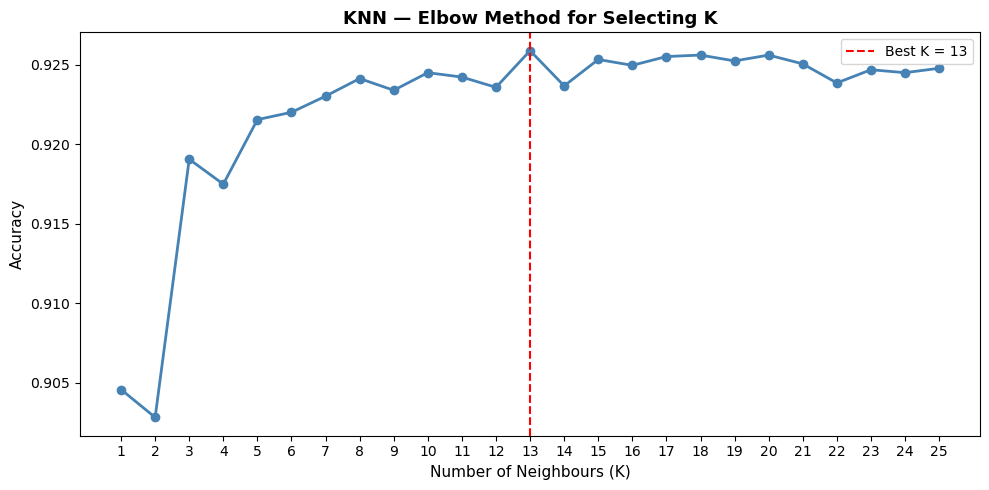

In [141]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), k_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k_elbow, color='red', linestyle='--', label=f'Best K = {best_k_elbow}')
ax.set_xlabel('Number of Neighbours (K)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('KNN — Elbow Method for Selecting K', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

In [142]:
print(f"Optimal K from elbow: {best_k_elbow}")

Optimal K from elbow: 13


##### Step 3: Hyperparameter Tuning

In [143]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski'],
    'algorithm'  : ['auto'],
    'leaf_size'  : [20, 30, 40]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


In [144]:
grid_knn.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 126 candidates, totalling 630 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto'], 'leaf_size': [20, 30, ...], 'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,13


In [145]:
print("BEST KNN PARAMETERS")
print(grid_knn.best_params_)
print(f"\nBest Cross-Validation Accuracy: {grid_knn.best_score_:.4f}")

BEST KNN PARAMETERS
{'algorithm': 'auto', 'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}

Best Cross-Validation Accuracy: 0.9264


In [146]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

In [147]:
print(f"KNN Test Accuracy (tuned): {knn_accuracy:.4f}")

KNN Test Accuracy (tuned): 0.9158


In [148]:
print("CLASSIFICATION REPORT — KNN")
print(classification_report(y_test, y_pred_knn, target_names=sorted(df['Class'].unique())))

CLASSIFICATION REPORT — KNN
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.94      0.94      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [149]:
classes = sorted(df['Class'].unique())
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=classes)


### Step4: Confusion Matrix

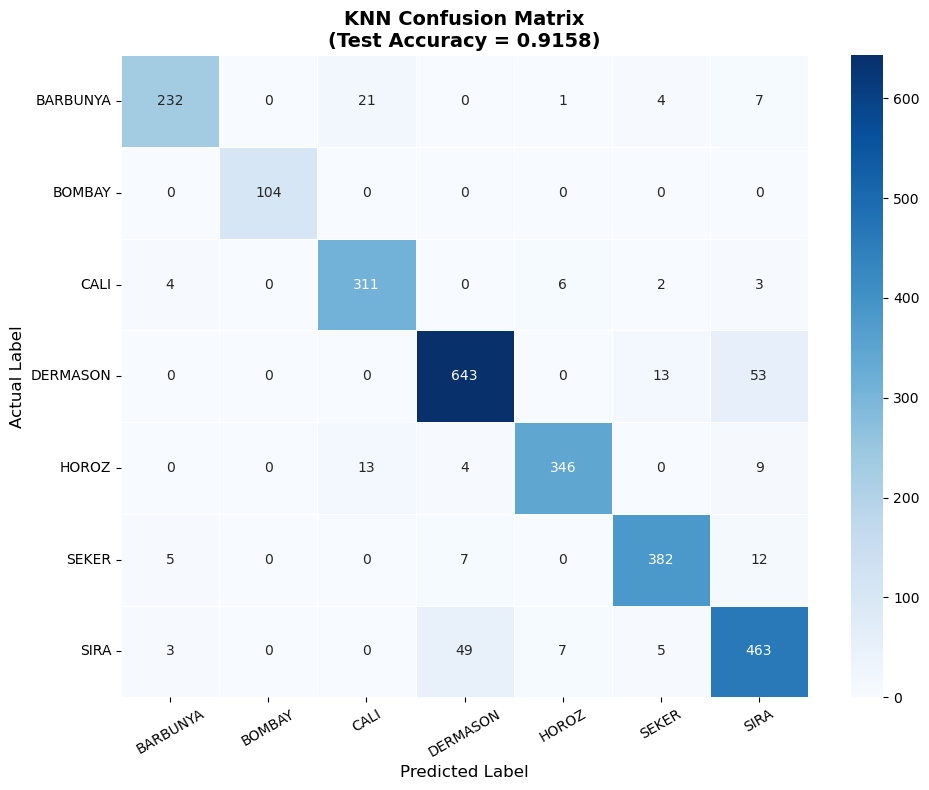

In [150]:
# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor='white'
)

ax.set_title(f'KNN Confusion Matrix\n(Test Accuracy = {knn_accuracy:.4f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Conclusion:**

* The tunned KNN models achieves high accuracy. The grid search identified the best combination of K, weight function, and distance metric.
* The confusion matrix reveals that 'DERMASON' and 'SIRA' are the most commonly confused pair - both are medium sized beans while 'BOMBAY' is nearly always classified correctly due to its large size.
* Limitation: KNN is slow at inference time for large datasets since it must compute distances to all training samples. It also requires features to be scaled.

#### 3.4 Model 2 - Decision Tree Classifier

The Decision tree recursively splits the training data along feature thresholds that maximally reduce impurity (measured by Gini Impurity or Entropy).

### Step 1: Baseline Decision Tree

In [151]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_dt_base = dt_base.predict(X_test)

In [152]:
print(f'The accuracy score base model: {accuracy_score(y_test, y_pred_dt_base):.4f}')

The accuracy score base model: 0.8966


In [153]:
print('Tree depth:', dt_base.get_depth())
print('Number of leaves:', dt_base.get_n_leaves())

Tree depth: 27
Number of leaves: 694


#### Step 2: Hyperparameter Tuning with GridSearchCV

In [154]:
param_grid_dt = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'max_features'     : ['sqrt', 'log2', None],
    'class_weight'     : [None, 'balanced']
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [155]:
grid_dt.fit(X_train, y_train)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [8, 10, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [156]:
print("BEST DECISION TREE PARAMETERS")
print(grid_dt.best_params_)
print(f"\nBest Cross-Validation Accuracy: {grid_dt.best_score_:.4f}")

BEST DECISION TREE PARAMETERS
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 12, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}

Best Cross-Validation Accuracy: 0.9127


In [157]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)



In [158]:
print(f"Decision Tree Test Accuracy (tuned): {dt_accuracy:.4f}")
print(f"Tree Depth:                          {best_dt.get_depth()}")
print(f"Number of Leaves:                    {best_dt.get_n_leaves()}")

Decision Tree Test Accuracy (tuned): 0.9033
Tree Depth:                          12
Number of Leaves:                    222


In [159]:
print("CLASSIFICATION REPORT — DECISION TREE")
print(classification_report(y_test, y_pred_dt, target_names=sorted(df['Class'].unique())))

CLASSIFICATION REPORT — DECISION TREE
              precision    recall  f1-score   support

    BARBUNYA       0.87      0.88      0.87       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.92      0.91       326
    DERMASON       0.92      0.90      0.91       709
       HOROZ       0.95      0.93      0.94       372
       SEKER       0.91      0.94      0.92       406
        SIRA       0.84      0.85      0.85       527

    accuracy                           0.90      2709
   macro avg       0.91      0.92      0.91      2709
weighted avg       0.90      0.90      0.90      2709



### Step 3: Confusion Matrix 

In [160]:
classes = sorted(df['Class'].unique())
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=classes)

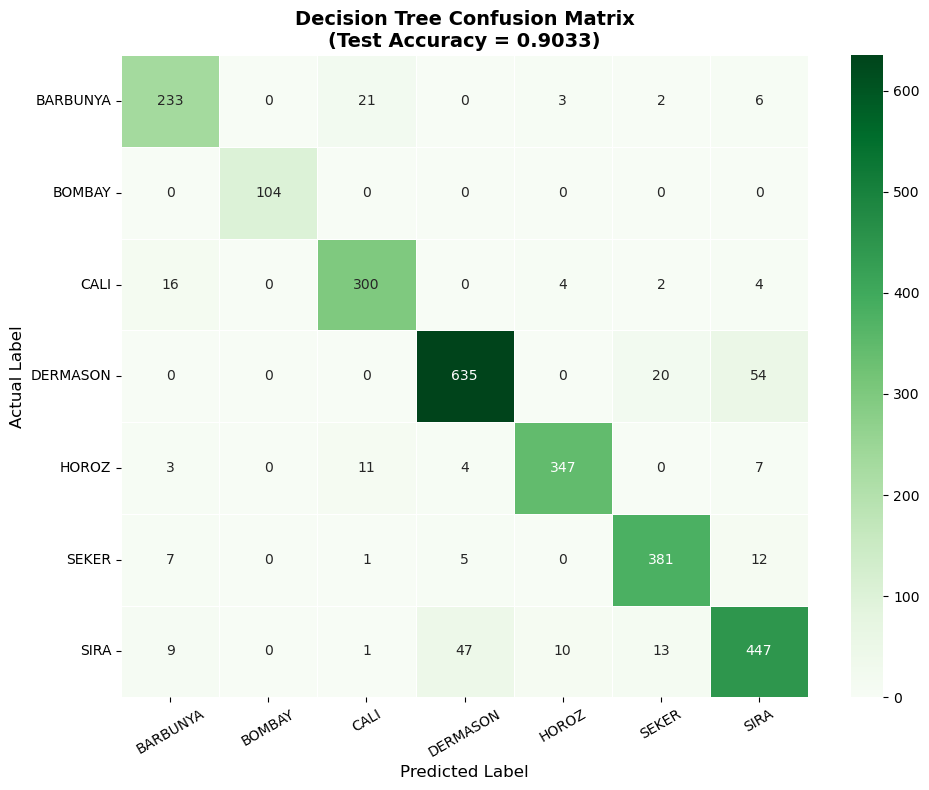

In [161]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor='white'
)

ax.set_title(f'Decision Tree Confusion Matrix\n(Test Accuracy = {dt_accuracy:.4f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


### Step 4: Identify the Feature Importance 

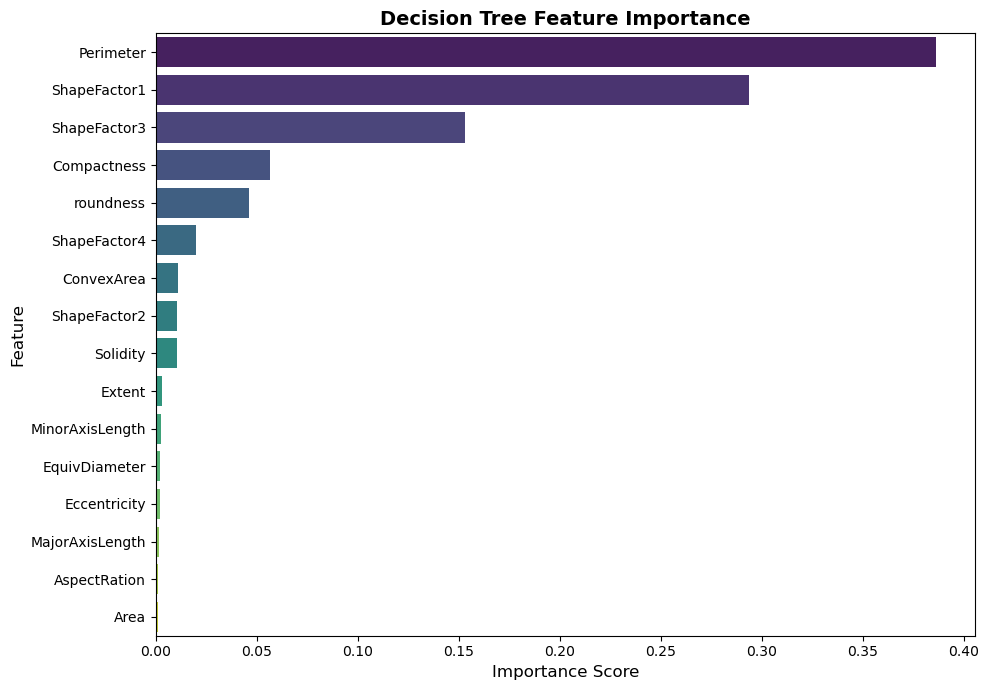

In [162]:

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Decision Tree Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.show()


**Conclusion:**
* The tuned decision tree achieves strong test accuracy with reasonable depth. Deep, unilimited trees overfit.
* ShapeFactor1, ShapeFactor2, MajorAxisLength, and Area emerge as the most important features. 


### Model Comparison

In [163]:
comparison = pd.DataFrame({
    'Model'    : ['KNN (Tuned)', 'Decision Tree (Tuned)'],
    'Accuracy' : [knn_accuracy, dt_accuracy],
    'CV Score' : [grid_knn.best_score_, grid_dt.best_score_]
})


print("MODEL ACCURACY COMPARISON")
print(comparison.to_string(index=False))

MODEL ACCURACY COMPARISON
                Model  Accuracy  CV Score
          KNN (Tuned)  0.915836  0.926436
Decision Tree (Tuned)  0.903285  0.912682


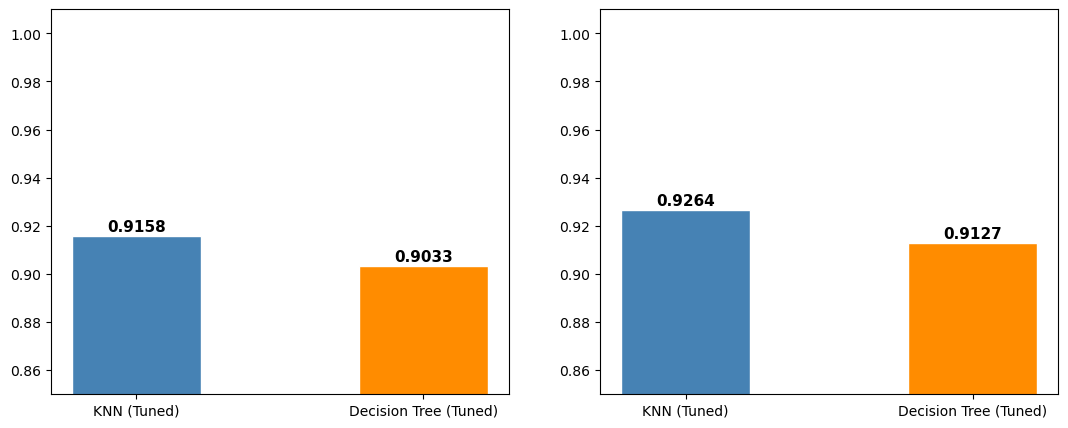

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes,
    ['Accuracy', 'CV Score'],
    ['Test Set Accuracy', '5-Fold Cross-Validation Score']
):
    bars = ax.bar(
        comparison['Model'],
        comparison[metric],
        color=['steelblue', 'darkorange'],
        width=0.45,
        edgecolor='white'
    )
    for bar, val in zip(bars, comparison[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    ax.set_ylim(0.85, 1.01)
    ax.set()

#### Final Recommendation

In [165]:
print("FINAL MODEL RECOMMENDATION")
print(f"KNN Test Accuracy:           {knn_accuracy:.4f}")
print(f"Decision Tree Test Accuracy: {dt_accuracy:.4f}")

FINAL MODEL RECOMMENDATION
KNN Test Accuracy:           0.9158
Decision Tree Test Accuracy: 0.9033


In [166]:
if knn_accuracy >= dt_accuracy:
    winner = 'KNN'
    print("RECOMMENDATION: KNN is the recommended model based on test accuracy.")
else:
    winner = 'Decision Tree'
    print("RECOMMENDATION: Decision Tree is the recommended model.")

RECOMMENDATION: KNN is the recommended model based on test accuracy.


#### Save the Best Model

In [167]:
joblib.dump(best_knn,    'best_knn_model.pkl')
joblib.dump(best_dt,     'best_decision_tree_model.pkl')
joblib.dump(scaler,      'scaler.pkl')

['scaler.pkl']

In [168]:
print("Models saved successfully.")

Models saved successfully.
